In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/stress-non-stress-images/KDEF/KDEF/Test/Stress/AM01ANHL.JPG
/kaggle/input/stress-non-stress-images/KDEF/KDEF/Test/Stress/BF22SUFL.JPG
/kaggle/input/stress-non-stress-images/KDEF/KDEF/Test/Stress/BM12AFHR.JPG
/kaggle/input/stress-non-stress-images/KDEF/KDEF/Test/Stress/AM08ANHL.JPG
/kaggle/input/stress-non-stress-images/KDEF/KDEF/Test/Stress/AM01DIHR.JPG
/kaggle/input/stress-non-stress-images/KDEF/KDEF/Test/Stress/BM19SUFR.JPG
/kaggle/input/stress-non-stress-images/KDEF/KDEF/Test/Stress/BF21ANFL.JPG
/kaggle/input/stress-non-stress-images/KDEF/KDEF/Test/Stress/BM04DIHR.JPG
/kaggle/input/stress-non-stress-images/KDEF/KDEF/Test/Stress/AM10SUS.JPG
/kaggle/input/stress-non-stress-images/KDEF/KDEF/Test/Stress/BM25SAS.JPG
/kaggle/input/stress-non-stress-images/KDEF/KDEF/Test/Stress/BF27AFHL.JPG
/kaggle/input/stress-non-stress-images/KDEF/KDEF/Test/Stress/AM13AFFR.JPG
/kaggle/input/stress-non-stress-images/KDEF/KDEF/Test/Stress/BM12AFS.JPG
/kaggle/input/stress-non-stress-images/KD

In [3]:
train_dir = '/kaggle/input/stress-non-stress-images/KDEF/KDEF/Train'
test_dir = '/kaggle/input/stress-non-stress-images/KDEF/KDEF/Test'

img_height, img_width = 224, 224
batch_size = 32
num_epochs = 100

In [4]:
# Import necessary libraries
import os
import numpy as np
import matplotlib.pyplot as plt
import itertools
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout

In [5]:
train_datagen = ImageDataGenerator(
    rescale = 1./255,
    rotation_range = 20,
    width_shift_range = 0.2,
    height_shift_range = 0.2,
    shear_range = 0.2,
    zoom_range = 0.2,
    horizontal_flip = True,
    validation_split = 0.2
)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size = (img_height, img_width),
    batch_size = batch_size,
    class_mode = 'binary',
    subset = 'training'
)

validation_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size = (img_height, img_width),
    batch_size = batch_size,
    class_mode = 'binary',
    subset = 'validation'
)

Found 3528 images belonging to 2 classes.
Found 881 images belonging to 2 classes.


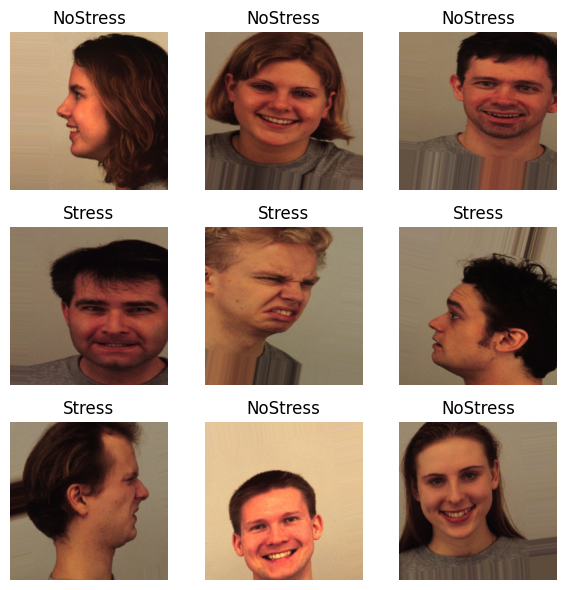

In [6]:
images, labels = next(train_generator)

class_names = list(train_generator.class_indices.keys())

plt.figure(figsize = (6, 6))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(images[i])
    plt.title(f"{class_names[int(labels[i])]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [7]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Model

In [8]:
from tensorflow.keras.callbacks import EarlyStopping,ModelCheckpoint
checkpoint_filepath = 'best_model.h5'

In [9]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, verbose=1, restore_best_weights=True),
]

In [10]:
## Evaluation
test_datagen = ImageDataGenerator(rescale = 1./255)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size = (img_height, img_width),
    batch_size = batch_size,
    class_mode = 'binary'
)

Found 1891 images belonging to 2 classes.


In [11]:
## WITH SIMPLE CNN

In [12]:
model = Sequential([

    Input(shape=(img_height, img_width, 3)),
    Conv2D(32, (3, 3), activation = 'relu'),
    MaxPooling2D(pool_size = (2, 2)),

    Conv2D(64, (3, 3), activation = 'relu'),
    MaxPooling2D(pool_size = (2, 2)),

    Conv2D(128, (3, 3), activation = 'relu'),
    MaxPooling2D(pool_size = (2, 2)),

    Conv2D(256, (3, 3), activation = 'relu'),
    MaxPooling2D(pool_size = (2, 2)),

    Flatten(),
    Dense(128, activation = 'relu'),
    Dropout(0.5),
    Dense(1, activation = 'sigmoid') # Binary classification
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 222, 222, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 111, 111, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 109, 109, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 54, 54, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 52, 52, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 26, 26, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 24, 24, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 12, 12, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 36864)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │       4,718,720 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 5,107,265 (19.48 MB)

 Trainable params: 5,107,265 (19.48 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
model.compile(
    optimizer = 'adam', 
    loss = 'binary_crossentropy',
    metrics = ['accuracy']
)

In [14]:
history1 = model.fit(train_generator, validation_data = validation_generator, epochs = 10,callbacks=callbacks)

Epoch 1/10


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


111/111 ━━━━━━━━━━━━━━━━━━━━ 91s 715ms/step - accuracy: 0.5565 - loss: 0.6817 - val_accuracy: 0.7616 - val_loss: 0.5424
Epoch 2/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 56s 475ms/step - accuracy: 0.7677 - loss: 0.5464 - val_accuracy: 0.7594 - val_loss: 0.5477
Epoch 3/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 56s 478ms/step - accuracy: 0.7700 - loss: 0.5254 - val_accuracy: 0.7696 - val_loss: 0.5185
Epoch 4/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 56s 480ms/step - accuracy: 0.7564 - loss: 0.5263 - val_accuracy: 0.7333 - val_loss: 0.5754
Epoch 5/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 55s 474ms/step - accuracy: 0.7543 - loss: 0.5266 - val_accuracy: 0.7707 - val_loss: 0.5180
Epoch 6/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 56s 476ms/step - accuracy: 0.7584 - loss: 0.5127 - val_accuracy: 0.7673 - val_loss: 0.4905
Epoch 7/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 55s 476ms/step - accuracy: 0.7704 - loss: 0.4902 - val_accuracy: 0.7673 - val_loss: 0.4756
Epoch 8/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 56s 477ms/step - accuracy: 0.7628 - loss: 0.5054 - val

In [15]:
test_loss, test_accuracy = model.evaluate(test_generator)
print(f"Test accuracy : {test_accuracy * 100:.2f}%")

60/60 ━━━━━━━━━━━━━━━━━━━━ 17s 277ms/step - accuracy: 0.7734 - loss: 0.4818
Test accuracy : 77.37%


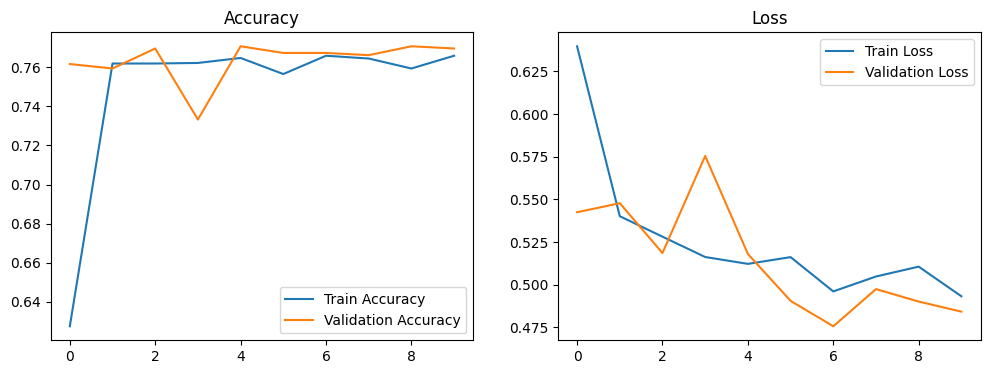

In [16]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history1.history['accuracy'], label='Train Accuracy')
plt.plot(history1.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history1.history['loss'], label='Train Loss')
plt.plot(history1.history['val_loss'], label='Validation Loss')
plt.title('Loss')
plt.legend()

plt.show()

In [17]:
import tensorflow as tf

In [18]:
conv_initializer = tf.keras.initializers.HeNormal()
regularizer = tf.keras.regularizers.l2(1e-4)

In [19]:
inputs = tf.keras.layers.Input(shape=(224, 224, 3))

# First Conv block
x = tf.keras.layers.Conv2D(32, (5, 5), activation=None,
                           kernel_initializer=conv_initializer,
                           kernel_regularizer=regularizer)(inputs)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Activation('relu')(x)
x = tf.keras.layers.MaxPooling2D((4, 4))(x)

# Second Conv block
x = tf.keras.layers.Conv2D(32, (3, 3), activation=None,
                           kernel_initializer=conv_initializer,
                           kernel_regularizer=regularizer)(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Activation('relu')(x)

# Third Conv block
x = tf.keras.layers.Conv2D(64, (3, 3), activation=None,
                           kernel_initializer=conv_initializer,
                           kernel_regularizer=regularizer)(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Activation('relu')(x)
x = tf.keras.layers.MaxPooling2D((2, 2))(x)

# Fourth Conv block
x = tf.keras.layers.Conv2D(64, (3, 3), activation=None,
                           kernel_initializer=conv_initializer,
                           kernel_regularizer=regularizer)(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Activation('relu')(x)

# Fifth Conv block
x = tf.keras.layers.Conv2D(128, (3, 3), activation=None,
                           kernel_initializer=conv_initializer,
                           kernel_regularizer=regularizer)(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Activation('relu')(x)

# Sixth Conv block
x = tf.keras.layers.Conv2D(128, (3, 3), activation=None,
                           kernel_initializer=conv_initializer,
                           kernel_regularizer=regularizer)(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Activation('relu')(x)
x = tf.keras.layers.MaxPooling2D((2, 2))(x)

# Seventh Conv block
x = tf.keras.layers.Conv2D(256, (3, 3), activation=None,
                           kernel_initializer=conv_initializer,
                           kernel_regularizer=regularizer)(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Activation('relu')(x)

# Classification head
x = tf.keras.layers.Flatten()(x)
x = tf.keras.layers.Dropout(0.5)(x)
# Change Dense layer to output 1 unit with sigmoid for binary classification
outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)

# Create the model
model2 = tf.keras.models.Model(inputs=inputs, outputs=outputs)

# Compile the model
model2.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
               loss='binary_crossentropy',
               metrics=['accuracy'])

# Optionally, view the model summary
model2.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 220, 220, 32)        │           2,432 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 220, 220, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation (Activation)              │ (None, 220, 220, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 55, 55, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 53, 53, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 53, 53, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_1 (Activation)            │ (None, 53, 53, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_6 (Conv2D)                    │ (None, 51, 51, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 51, 51, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_2 (Activation)            │ (None, 51, 51, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 25, 25, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (None, 23, 23, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 23, 23, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_3 (Activation)            │ (None, 23, 23, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_8 (Conv2D)                    │ (None, 21, 21, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 21, 21, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_4 (Activation)            │ (None, 21, 21, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_9 (Conv2D)                    │ (None, 19, 19, 128)         │         147,5

 Total params: 599,073 (2.29 MB)

 Trainable params: 597,665 (2.28 MB)

 Non-trainable params: 1,408 (5.50 KB)

In [20]:
from tensorflow.keras.callbacks import EarlyStopping,ReduceLROnPlateau,ModelCheckpoint

es=EarlyStopping(monitor='val_accuracy',patience=10,verbose=1,mode='max')
lr = ReduceLROnPlateau(monitor='val_accuracy', mode = 'max', patience=3, factor=0.5, min_lr=1e-30, verbose = 2)
mc=ModelCheckpoint(filepath='best.keras',monitor='val_accuracy',save_best_only=True,mode='max')
callback=[es,lr,mc]

In [21]:
history2=model2.fit(
    train_generator, 
    validation_data = validation_generator, 
    epochs = 100,
    callbacks=callback
)

Epoch 1/100
111/111 ━━━━━━━━━━━━━━━━━━━━ 75s 546ms/step - accuracy: 0.6972 - loss: 0.8252 - val_accuracy: 0.4449 - val_loss: 11.4235 - learning_rate: 0.0010
Epoch 2/100
111/111 ━━━━━━━━━━━━━━━━━━━━ 55s 471ms/step - accuracy: 0.7188 - loss: 0.6920 - val_accuracy: 0.7616 - val_loss: 0.6564 - learning_rate: 0.0010
Epoch 3/100
111/111 ━━━━━━━━━━━━━━━━━━━━ 57s 481ms/step - accuracy: 0.7575 - loss: 0.6617 - val_accuracy: 0.7026 - val_loss: 1.0207 - learning_rate: 0.0010
Epoch 4/100
111/111 ━━━━━━━━━━━━━━━━━━━━ 56s 482ms/step - accuracy: 0.7512 - loss: 0.6811 - val_accuracy: 0.7594 - val_loss: 0.6501 - learning_rate: 0.0010
Epoch 5/100
111/111 ━━━━━━━━━━━━━━━━━━━━ 56s 475ms/step - accuracy: 0.7573 - loss: 0.6389 - val_accuracy: 0.7707 - val_loss: 0.6076 - learning_rate: 0.0010
Epoch 6/100
111/111 ━━━━━━━━━━━━━━━━━━━━ 56s 480ms/step - accuracy: 0.7576 - loss: 0.6315 - val_accuracy: 0.7628 - val_loss: 0.6930 - learning_rate: 0.0010
Epoch 7/100
111/111 ━━━━━━━━━━━━━━━━━━━━ 57s 487ms/step - accur

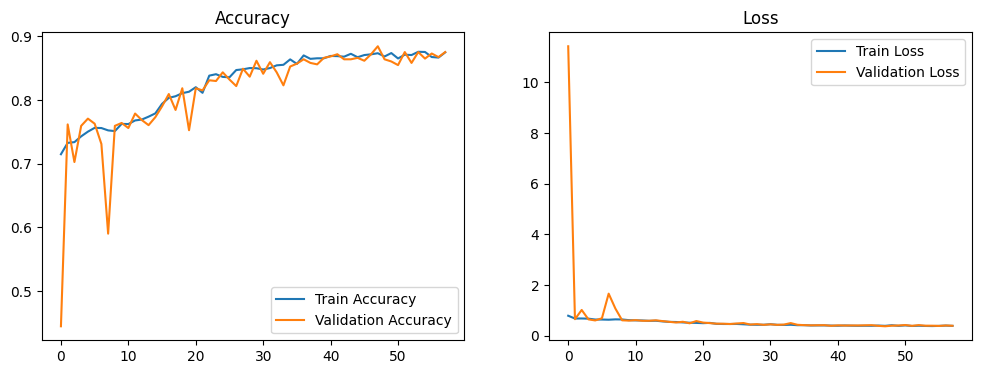

In [23]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history2.history['accuracy'], label='Train Accuracy')
plt.plot(history2.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history2.history['loss'], label='Train Loss')
plt.plot(history2.history['val_loss'], label='Validation Loss')
plt.title('Loss')
plt.legend()

plt.show()

In [24]:
test_loss, test_accuracy = model2.evaluate(test_generator)
print(f"Test accuracy : {test_accuracy * 100:.2f}%")

60/60 ━━━━━━━━━━━━━━━━━━━━ 12s 208ms/step - accuracy: 0.8850 - loss: 0.4339
Test accuracy : 88.52%


In [25]:
model2.save('model2.h5')

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 821ms/step


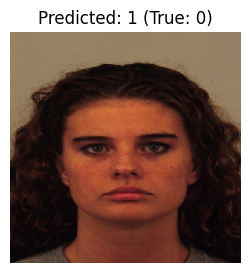

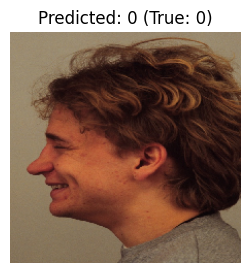

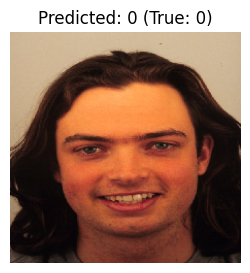

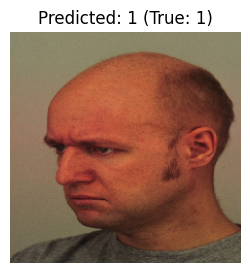

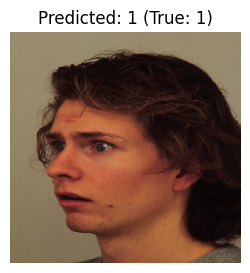

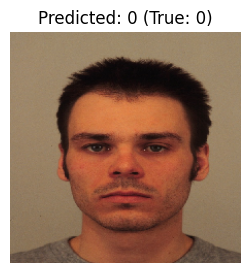

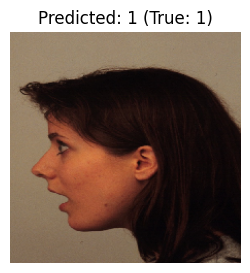

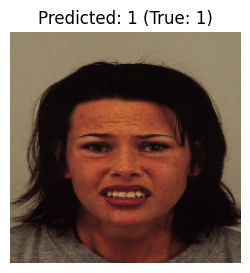

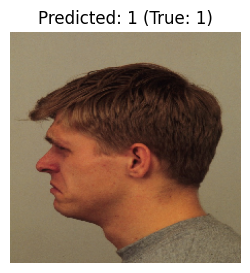

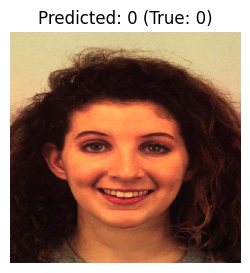

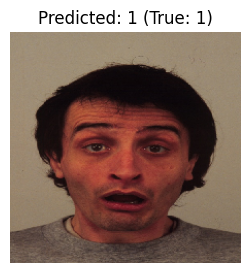

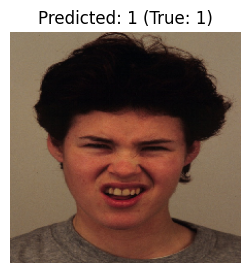

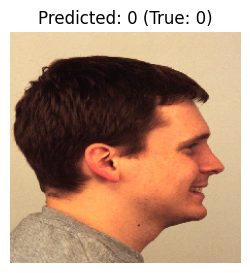

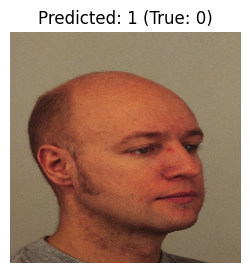

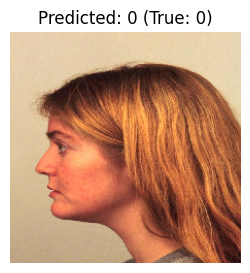

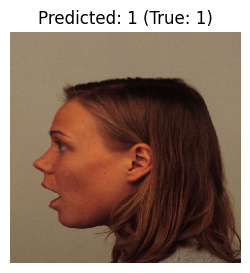

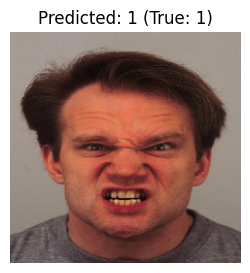

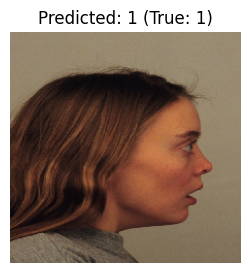

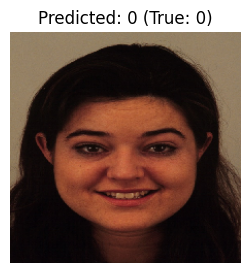

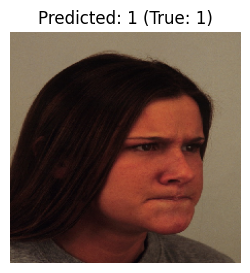

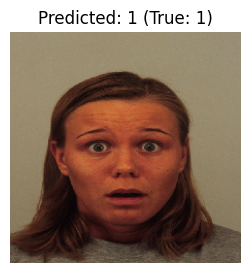

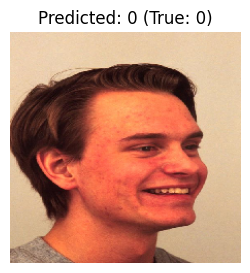

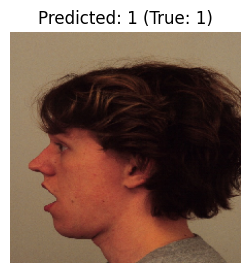

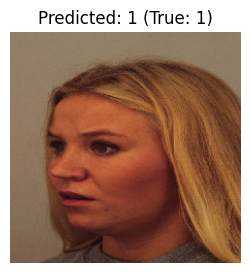

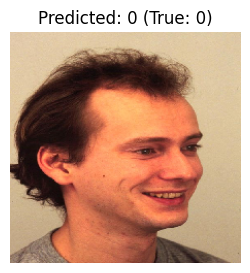

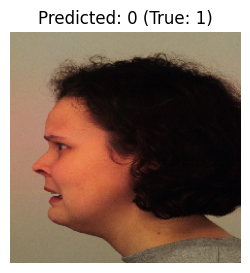

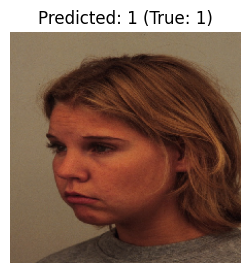

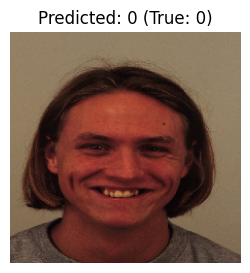

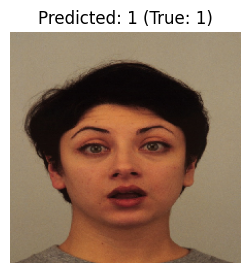

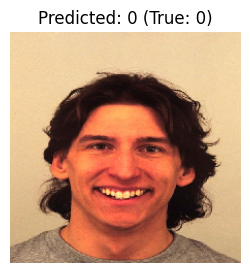

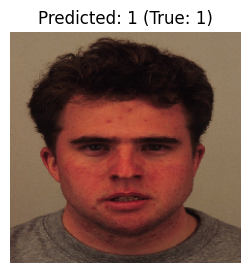

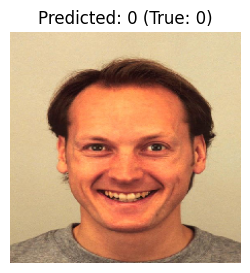

In [26]:
## PLOT SOME PREDICTION 
images, labels = next(test_generator)

# Predict probabilities for this batch
predictions = model2.predict(images)

# Convert predicted probabilities into binary labels (0 or 1)
predicted_classes = (predictions > 0.5).astype(int).flatten()

# Display each image with its predicted and true labels
for i in range(len(images)):
    plt.figure(figsize=(3,3))
    # The images from the generator are already scaled (rescale=1./255)
    plt.imshow(images[i])
    plt.title(f"Predicted: {predicted_classes[i]} (True: {int(labels[i])})")
    plt.axis('off')
    plt.show()